<a href="https://colab.research.google.com/github/amrit2603/Gen-AI/blob/main/LANGCHAIN_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain

In [3]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

!pip install langchain_groq
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.2 MB/s eta 0:00:00


In [4]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to Bhojpuri. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke("what is neural network?")
print(f"response: {ai_msg.content}")

response: A **neural network** is a computational model inspired by the structure and function of the human brain. It is a fundamental component of machine learning and artificial intelligence, designed to recognize patterns, make decisions, and solve complex problems by learning from data. Here's a structured breakdown of its key aspects:

---

### **Core Components**
1. **Neurons (Nodes):**
   - Artificial neurons mimic biological neurons. Each neuron receives inputs, processes them, and produces an output.
   - **Inputs:** Numerical values (e.g., pixel intensities in an image).
   - **Weights:** Parameters that determine the strength of connections between neurons. Adjusted during training.
   - **Bias:** An additional parameter that allows shifting the activation function.
   - **Activation Function:** Introduces non-linearity (e.g., ReLU, sigmoid, tanh). Enables the network to model complex relationships.

2. **Layers:**
   - **Input Layer:** Receives raw data (e.g., image pixels)

In [5]:
from langchain_core.prompts import ChatPromptTemplate


travel_template="Suggest me  name of a famouse place in one word only to travel on a {location}."

prompt_template = ChatPromptTemplate.from_messages([("system",travel_template),("user","{location}")])

In [6]:
prompt=prompt_template.invoke({"location":"Patna"})
llm.invoke(prompt)

AIMessage(content='**Golghar**', additional_kwargs={'reasoning_content': 'Okay, the user is asking for a famous place in Patna that can be named in one word. Let me think about Patna\'s notable landmarks.\n\nFirst, I know Patna is a historical city in Bihar, India. It has a lot of ancient sites. The most famous one that comes to mind is the Patna Museum. But wait, the user wants a one-word name. "Patna Museum" is two words. Hmm, maybe there\'s another name for it? Let me check.\n\nOh, right! The Patna Museum is also known as the Bihar State Museum. Still two words. Maybe there\'s a shorter name? Wait, sometimes places have alternative names. Let me think again.\n\nAnother famous site is the Golghar. That\'s a single word. The Golghar is a large granary built during the British era. It\'s a prominent landmark in Patna. Yes, that\'s one word. I think that\'s the answer. Let me confirm if there are other one-word famous places. There\'s also the Takht Sri Patna Sahib, a significant Sikh t

In [7]:
prompt_template=ChatPromptTemplate.from_template("Suggest me  name of a famouse place in one word only to travel on a {country} in the month of {month}.")
prompt=prompt_template.invoke({"country":"India","month":"January"})

print(prompt)

response=llm.invoke(prompt)
response.content

messages=[HumanMessage(content='Suggest me  name of a famouse place in one word only to travel on a India in the month of January.', additional_kwargs={}, response_metadata={})]


'**Agra**'

# **CHAINING**

In [8]:
from langchain_core.output_parsers import StrOutputParser

travel_destination_chain = prompt_template | llm | StrOutputParser()

# travel_destination_chain.invoke({"country": "India", "month": "December"})

travel_itinerary_prompt = ChatPromptTemplate.from_template(
    "Give me 5 days itinerary for the place {destination}"
)

composed_chain = {"destination": travel_destination_chain} | travel_itinerary_prompt | llm | StrOutputParser()
# here the number of times llm is used is 2 times
# first to get the destination and second to get the itinerary then the final output is parsed using StrOutputParser

composed_chain.invoke({"country": "India", "month": "December"})

"**5-Day Goa Itinerary: Christmas & New Year's Eve Festivities with Serene Beaches**  \nGoa in December is a magical blend of vibrant celebrations and tranquil coastal beauty. Here's a curated itinerary to balance festive cheer, cultural experiences, and relaxation:\n\n---\n\n### **Day 1: Arrival & Christmas in Old Goa**  \n**Morning:**  \n- Arrive in Goa and check into a beachfront resort or boutique hotel in **North Goa** (e.g., Baga, Calangute, or Anjuna).  \n- Visit **Old Goa** (Chapora Fort, Se Cathedral, and St. Cajetan Church) to witness colonial architecture and Christmas decorations.  \n\n**Afternoon:**  \n- Lunch at a local Goan restaurant (try **Goan fish curry** and **biryani**).  \n- Explore **Mapusa Market** for festive souvenirs, spices, and Christmas decorations.  \n\n**Evening:**  \n- Attend a **Christmas market** in Anjuna or Arambol (December 24–25).  \n- Dinner at **Café del Mar** or **The Bay** for a festive meal with ocean views.  \n\n**Night:**  \n- Optional: Att

In [9]:
# Now below is the Problem
llm.invoke(" whos is pm of india")

AIMessage(content="As of October 2023, the **Prime Minister of India is Narendra Modi**. He has been in office since May 26, 2014, and was re-elected for a second term in 2019. \n\n### Key Details:\n- **Political Party**: Bharatiya Janata Party (BJP).\n- **Tenure**: First elected in 2014, re-elected in 2019. His third term began in June 2024 after the BJP's victory in the 2024 general elections.\n- **Significance**: Modi is the longest-serving Prime Minister since independence (1947) and has implemented major policies like the Goods and Services Tax (GST), Swachh Bharat (Clean India) campaign, and digital India initiatives.\n\nFor the most up-to-date information, always verify with recent news or official government sources.", additional_kwargs={'reasoning_content': "Okay, the user is asking who the Prime Minister of India is. Let me start by recalling the current political situation in India. As of my last update, Narendra Modi has been serving as the Prime Minister. He was first elec

# problem with llm by default doesnt remeber previous **chat**

In [10]:
# LLM bydefault does not remember the previous chat
llm.invoke("whats his age")

AIMessage(content='To provide an accurate answer, could you clarify who "his" refers to? For example, if you\'re asking about a character like Goku from *Dragon Ball*, he is typically portrayed as being in his late 30s to early 40s in the series (e.g., 44 in *Dragon Ball Super: Super Hero*). If you meant someone else, let me know!', additional_kwargs={'reasoning_content': 'Okay, the user is asking "whats his age" but didn\'t specify who "his" refers to. I need to figure out who they\'re talking about. Let me check the conversation history.\n\nLooking back, the previous messages were about a character named Goku from Dragon Ball. The user asked about Goku\'s age in the latest movie, and I provided an answer. Now, the user is asking "whats his age" again. Since the last context was about Goku, it\'s safe to assume they\'re still referring to him. \n\nI should confirm if they mean Goku, but maybe they just want a direct answer. Let me make sure. If they are indeed asking about Goku\'s age

# **LangGraph**

In [11]:
from langgraph.graph import StateGraph

from typing import TypedDict

class State(TypedDict):
    x: int
    y: int
    result: int

In [12]:
def func1(state):
    """Adds x and y"""
    x = state["x"]
    y = state["y"]
    result = x + y
    return {"result": result}

def func2(state):
    """Multiplies result by 2"""
    result = state["result"]
    return {"result": 2 * result}

In [13]:
# Initialize the graph with your state schema
workflow = StateGraph(State)

# Add your nodes
workflow.add_node("node_1", func1)
workflow.add_node("node_2", func2)

# Define the flow
workflow.add_edge("node_1", "node_2")

# Set where to start
workflow.set_entry_point("node_1")

# Set end point
workflow.set_finish_point("node_2")

# Compile the graph
app = workflow.compile()

In [14]:
app = workflow.compile()

result = app.invoke({"x": 5, "y": 10})
result

{'x': 5, 'y': 10, 'result': 30}

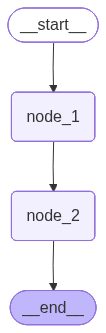

In [15]:
from IPython.display import Image, display

# Visualize the graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error displaying graph: {e}")

# Query Customer Support **App**

In [16]:
from typing_extensions import TypedDict, Dict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

In [17]:
from typing import TypedDict

class State(TypedDict):
    query:str
    category:str
    sentiment:str
    response:str

llm.invoke("what is langchain in 20 words?")

AIMessage(content='LangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots.', additional_kwargs={'reasoning_content': 'Okay, the user is asking for a 20-word explanation of LangChain. Let me start by recalling what LangChain is. It\'s a framework for building applications with large language models. I need to mention its key features like modularity, integration with various models, and tools for data handling. Also, it\'s used for creating chatbots, agents, and more. Let me check if I can condense that into 20 words without losing the main points. Maybe start with "LangChain is a framework for building LLM-powered apps with modularity, integrations, and tools for data, agents, and chatbots." Let me count the words. That\'s 20. It covers the main aspects: framework, LLM-powered apps, modularity, integrations, tools, and specific use cases. I think that works.\n'}, response_metadata={'token_usage': {'completion_token

In [18]:
def categorize(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        "Categorize the following query into one of the following categories: "
        "Technical, Billing, General. Query: {query}"
    )
    chain = prompt | llm
    category = chain.invoke({"query": state["query"]}).content
    print(f"\nCategory : {category}")
    return {"category": category}


def analyze_sentiment(state: State) -> State:
    print("\nAnalyzing the sentiment : ")
    prompt = ChatPromptTemplate.from_template(
        "Analyze the sentiment of the following customer query and ans in word "
        "Response with either 'Positive', 'Neutral', or 'Negative'. Query: {query}"
    )
    chain = prompt | llm
    sentiment = chain.invoke({"query": state["query"]}).content
    print(f"\nSentiment : {sentiment}")
    return {"sentiment": sentiment}


def handle_technical(state: State) -> State:
    print("\nHandling the technical query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a technical support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def handle_billing(state: State) -> State:
    print("\nHandling the billing query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a billing support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def handle_general(state: State) -> State:
    print("\nHandling the general query")
    prompt = ChatPromptTemplate.from_template(
        "Provide a general support response to the following query : {query}"
    )
    chain = prompt | llm
    response = chain.invoke({"query": state["query"]}).content
    return {"response": response}


def escalate(state: State) -> State:
    print("Escalating Query")
    return {
        "response": "This query has been escalate to a human agent due to its negative sentiment"
    }

def route_query(state: State) -> str:  # Changed from State to str
    if state["sentiment"] == "Negative":
        return "escalate"
    elif state["category"] == "Technical":
        return "handle_technical"
    elif state["category"] == "Billing":
        return "handle_billing"
    else:
        return "handle_general"

In [19]:
workflow = StateGraph(State)

workflow.add_node("categorize", categorize)
workflow.add_node("analyze_sentiment", analyze_sentiment)
workflow.add_node("handle_technical", handle_technical)
workflow.add_node("handle_billing", handle_billing)
workflow.add_node("handle_general", handle_general)
workflow.add_node("escalate", escalate)

workflow.set_entry_point("categorize")

workflow.add_edge("categorize", "analyze_sentiment")

# Add conditional edges with explicit paths
workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    ["escalate", "handle_technical", "handle_billing", "handle_general"]
)

workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)

app = workflow.compile()

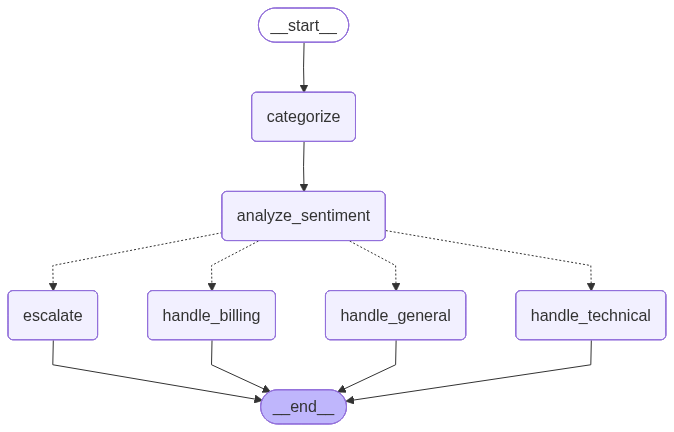

In [20]:
from IPython.display import Image, display

# Visualize the graph
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error displaying graph: {e}")

In [21]:
def run_customer_support(query: str) -> Dict[str, str]:
    results = app.invoke({"query": query})
    return {
        "category": results["category"],
        "sentiment": results["sentiment"],
        "response": results["response"]
    }

In [22]:
query = "The price value in my invoice is wrong"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : The query "The price value in my invoice is wrong" falls under the **Billing** category. This is because the user is directly addressing an issue related to the accuracy of charges or pricing on an invoice, which is a core aspect of billing concerns. While technical errors could potentially cause such discrepancies, the user's focus is on the financial details rather than system functionality. 

**Category:** Billing

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: The price value in my invoice is wrong


Category: The query "The price value in my invoice is wrong" falls under the **Billing** category. This is because the user is directly addressing an issue related to the accuracy of charges or pricing on an invoice, which is a core aspect of billing concerns. While technical errors could potentially cause such discrepancies, the user's focus is on the financial details rather than system functionality. 

**Category:** Billing


S

In [23]:
query = "my iphone isnt working"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : The query "my iPhone isn't working" falls under the **Technical** category. This is because it relates to a potential malfunction or issue with the device's functionality, which typically requires technical troubleshooting or support.

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: my iphone isnt working


Category: The query "my iPhone isn't working" falls under the **Technical** category. This is because it relates to a potential malfunction or issue with the device's functionality, which typically requires technical troubleshooting or support.


Sentiment: Negative


Response: This query has been escalate to a human agent due to its negative sentiment




In [24]:
query = "I purchased the iphone 16 but its screen is broken. This is not the kind of service I was expecting"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : The query is categorized as **Technical**. 

**Reasoning**: The user reports a hardware issue (broken screen) with their iPhone 16, which falls under technical problems related to product functionality. While the mention of "service" could imply dissatisfaction with customer support, the primary concern is the physical defect in the device itself, making "Technical" the most accurate category.

Analyzing the sentiment : 

Sentiment : Negative
Escalating Query


Computed Result
Query: I purchased the iphone 16 but its screen is broken. This is not the kind of service I was expecting


Category: The query is categorized as **Technical**. 

**Reasoning**: The user reports a hardware issue (broken screen) with their iPhone 16, which falls under technical problems related to product functionality. While the mention of "service" could imply dissatisfaction with customer support, the primary concern is the physical defect in the device itself, making "Technical" the most accurate 

In [25]:
query = "I am really happy with the service and I want invoice for my new purchase"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : The query is categorized as **Billing**. The user is requesting an invoice for a new purchase, which directly relates to billing and financial transactions. The mention of being happy with the service is a general comment but does not affect the category.

Analyzing the sentiment : 

Sentiment : Positive

Handling the general query


Computed Result
Query: I am really happy with the service and I want invoice for my new purchase


Category: The query is categorized as **Billing**. The user is requesting an invoice for a new purchase, which directly relates to billing and financial transactions. The mention of being happy with the service is a general comment but does not affect the category.


Sentiment: Positive


Response: Thank you for your kind words and for choosing our service—we’re thrilled to hear you’re happy with your purchase! 🌟  

To assist you with your invoice, could you please provide the **order number** or the **email associated with your purchase**? This w

In [26]:
query = "When is the new iphone will launching?"
result = run_customer_support(query)

print("\n\nComputed Result")
print(f"Query: {query}")
print(f"\n\nCategory: {result['category']}")
print(f"\n\nSentiment: {result['sentiment']}")
print(f"\n\nResponse: {result['response']}")
print("\n")


Category : The query "When is the new iPhone will launching?" falls under the **General** category. It pertains to product availability and company announcements rather than technical specifications or billing-related concerns.

Analyzing the sentiment : 

Sentiment : Positive

Handling the general query


Computed Result
Query: When is the new iphone will launching?


Category: The query "When is the new iPhone will launching?" falls under the **General** category. It pertains to product availability and company announcements rather than technical specifications or billing-related concerns.


Sentiment: Positive


Response: Apple typically launches its new iPhone models in **September each year**, following a keynote event where they unveil the latest devices. While no official announcement has been made for the 2024 iPhone lineup, historical trends suggest the **iPhone 16 series** could be revealed in **early September 2024** (likely around the 9th–12th), with a public release expec